In [1]:
import pandas as pd

df = pd.read_csv('../data/country_wise_latest.csv')
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [2]:
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [3]:
df = df.fillna(0)

df.columns = df.columns.str.strip()

df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


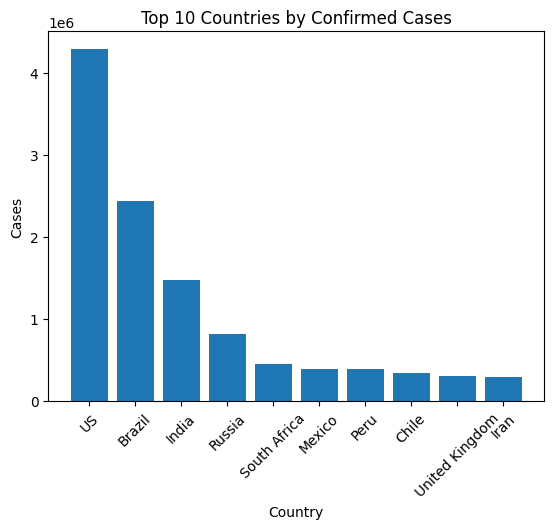

In [9]:
import matplotlib.pyplot as plt

top10 = df.sort_values(by='Confirmed', ascending=False).head(10)

plt.figure()
plt.bar(top10['Country/Region'], top10['Confirmed'])
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Confirmed Cases")
plt.xlabel("Country")
plt.ylabel("Cases")
plt.savefig('../output/top10_cases.png')
plt.show()

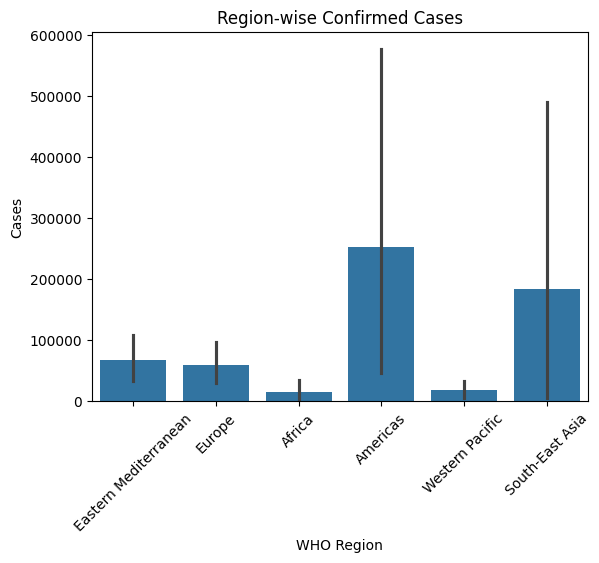

In [14]:
import seaborn as sns

plt.figure()
sns.barplot(x='WHO Region', y='Confirmed', data=df)
plt.xticks(rotation=45)
plt.title("Region-wise Confirmed Cases")
plt.xlabel("WHO Region")
plt.ylabel("Cases")
plt.savefig('../output/region_cases.png')
plt.show()

In [6]:
# Create new columns
df['Death Rate'] = (df['Deaths'] / df['Confirmed']) * 100
df['Recovery Rate'] = (df['Recovered'] / df['Confirmed']) * 100

df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,Death Rate,Recovery Rate
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,3.499435,69.486805
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,2.950820,56.250000
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,4.157581,67.339935
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,5.733186,88.533627
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,4.315789,25.473684


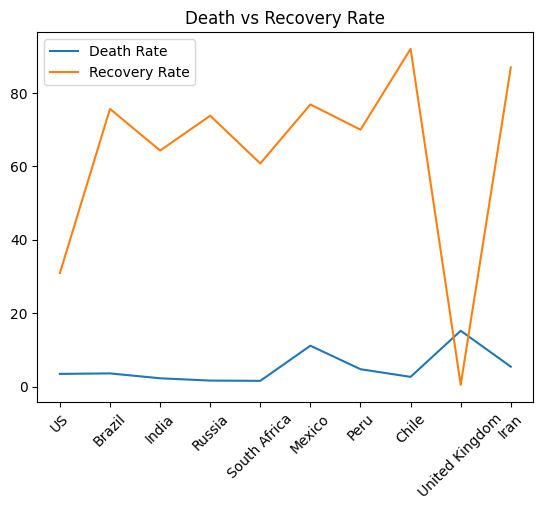

In [11]:
top10 = df.sort_values(by='Confirmed', ascending=False).head(10)

plt.figure()
plt.plot(top10['Country/Region'], top10['Death Rate'], label='Death Rate')
plt.plot(top10['Country/Region'], top10['Recovery Rate'], label='Recovery Rate')
plt.xticks(rotation=45)
plt.legend()
plt.title("Death vs Recovery Rate")
plt.savefig('../output/rates.png')
plt.show()